In [1]:
]activate ../../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [2]:
using Revise
includet("./base.jl")

In [3]:
using GLMakie
using CairoMakie
CairoMakie.activate!()

In [4]:
BLAS.set_num_threads(1)

# Generate systems, solve ODE, filter and test

In [6]:
K = 10.
l = 0.999
T = 1e8
tol = 1e-9
@time df = solve_si_odes("test1.jld2", 100,
    K, l,
    T, tol,
);
count(df.good), nrow(df)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:40

 40.125563 seconds (4.23 M allocations: 319.622 MiB, 0.42% gc time, 0.02% compilation time: 53% of which was recompilation)

(49, 100)

## Or load previous one

In [5]:
close(f)
df = nothing
GC.gc()

LoadError: UndefVarError: `f` not defined

In [5]:
f = jldopen("./test2.jld2")
fmd = f["metadata"]

K = fmd.K
l = fmd.l
T = fmd.T
tol = fmd.reltol

Ns = fmd.N

df = f["df"];
count(df.good), nrow(df)

(6256, 10000)

## Test some disprels

Progress: 100%|█████████████████████████████████████████| Time: 0:00:09

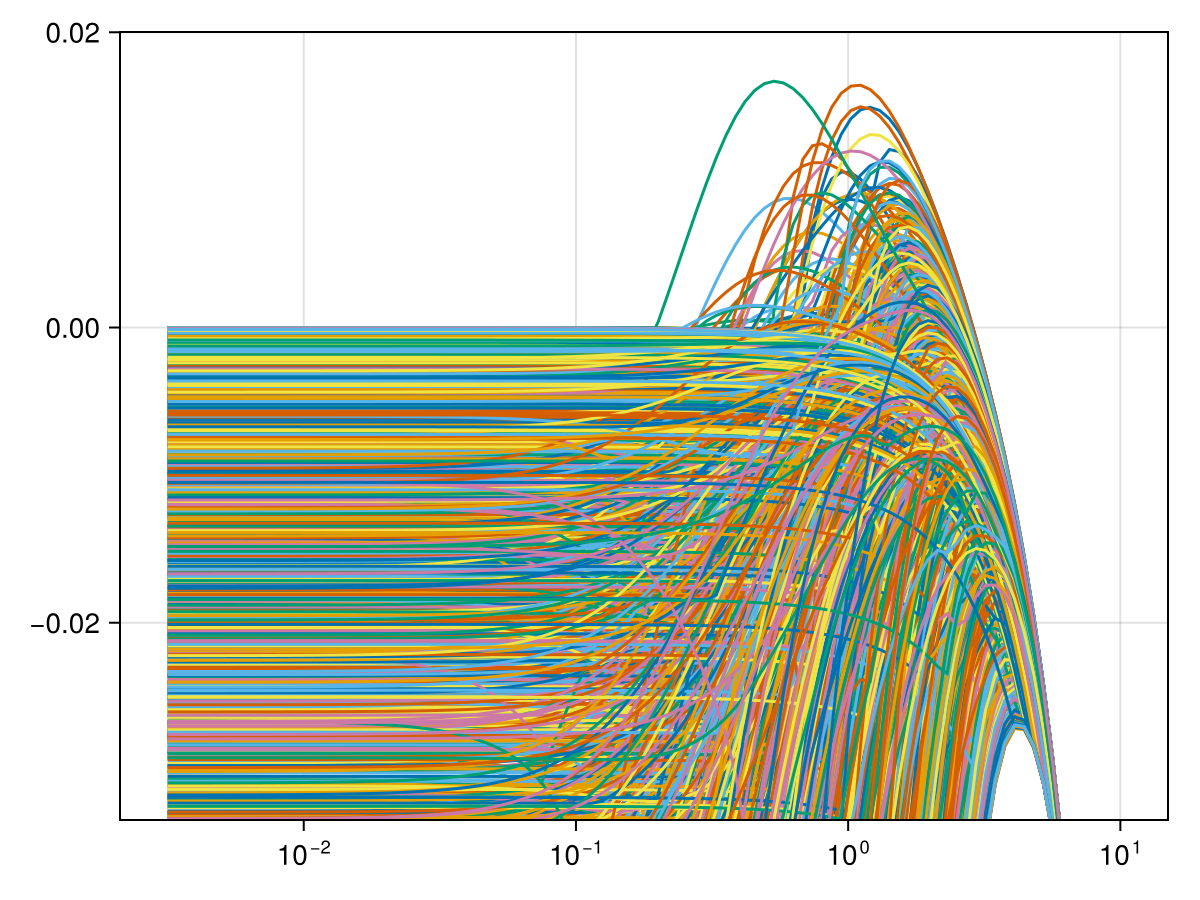

In [11]:
ks = 10 .^ range(-2.5, 1, 100)
DN = 1e-3
p = 1e1
(; Ds, mrls) = si_disprels(df, ks, DN, 1., p);

fig = Figure()
ax = Axis(fig[1,1]; xscale=log10)

for i in 1:nrow(df)
    if df.good[i]
        lines!(ks, mrls[i])
    end
end

mm = abs(maximum(maximum.(mrls[df.good])))
# xlims!(ax, 1e0, 1e2)
ylims!(ax, (-2., 1.2) .* mm)

fig

In [19]:
display(GLMakie.Screen(), fig)

GLMakie.Screen(...)

count((mm->begin
            #= In[23]:1 =#
            maximum(mm) > 0.1
        end), mrls) = 150

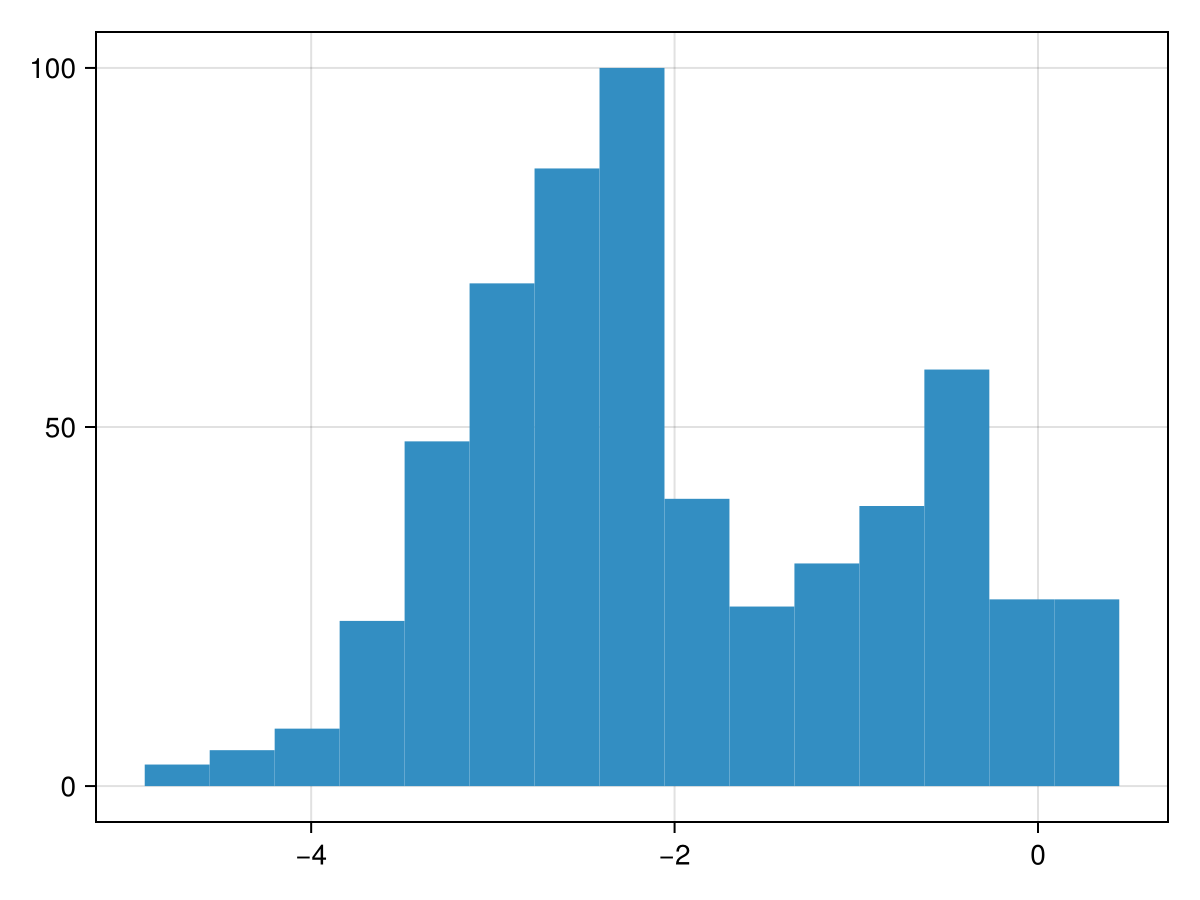

In [23]:
@show count(mm->maximum(mm)>1e-1, mrls)
hist(log10.(filter(>(1e-20), maximum.(mrls))))

# Removing extinct strains

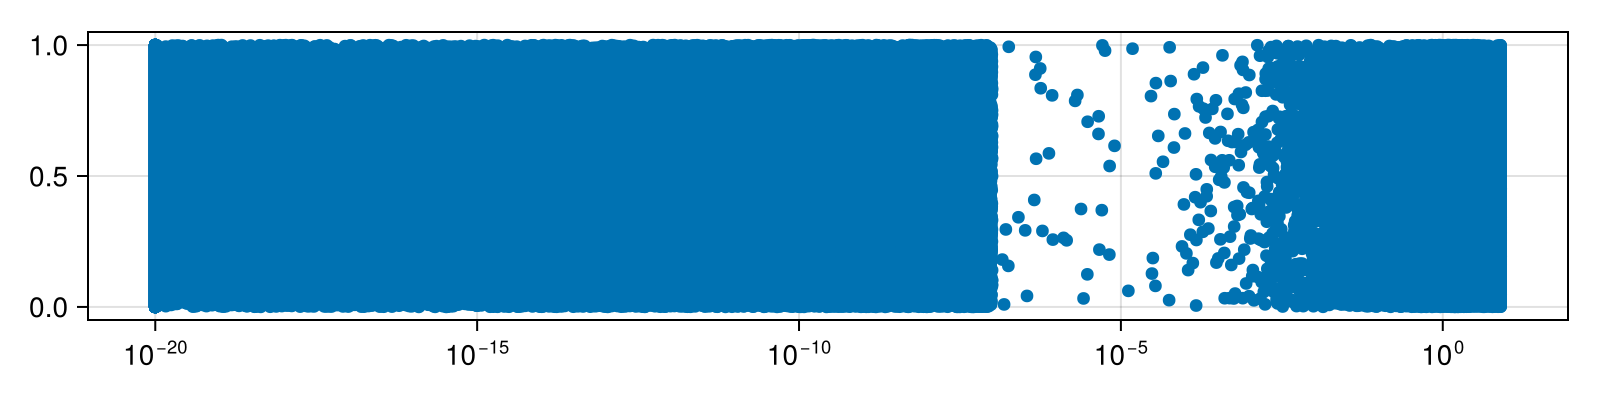

In [20]:
xx = vcat(getindex.(df.final_states, Ref(1:20))...)
scatter(clamp.(xx, 1e-20, Inf), rand(length(xx));
    figure=(;
        size=(800, 200),
    ),
    axis=(;
        xscale=log10,
    ),
)

In [6]:
extinction_threshold = 1e-6

df = df[df.good,[:params,:final_states]]
df.df_row = 1:nrow(df)

for r in eachrow(df)
    xx = reduce_extinct(r.params, r.final_states, extinction_threshold)
    r.params = xx.params
    r.final_states = xx.final_state
end

xx = get_Ns.(df.params)
df.Ns = getindex.(xx, 1)
df.Nr = getindex.(xx, 2);

In [7]:
maxresids = [mmicrmmaxresid(r.final_states, r.params) for r in eachrow(df)]
extrema(maxresids)

(0.0, 9.765933839389618e-9)

# Disprels ps, find a sensible system size and prep for PDE runs

In [8]:
num_systems = 100

# disprels and peak finding
ks = 10 .^ range(-2, 2, 200)  # grid the peak k gets read off, no root finding
ps = 10 .^ range(-2, 0, 3)          # byproduct diffusions (DR) to compare each system at
DN = 1e-3                      # strain diffusion
DI = 1.0                       # influx resource diffusion

# system size and spatial u0
num_peaks = 1    # peaks each domain fits; L is set per (system, p) from its own peak k
sN = 250         # spatial gridpoints, same for every run so dx varies with L
epsilon = 1e-2   # uniform, proportional +/- perturbation added to the ODE steady state
seed = 1         # so the u0s can be regenerated
T = T            # PDE end time, same as the ODE T in the section above

out_fname = "systems2.jld2"

"systems2.jld2"

In [9]:
(; mrls, peak_ks, peak_hs, at_edge) = disprel_peak_ks(df, ks, DN, DI, ps)

# peaks on the edge of the ks range are not real peaks - widen ks if any turn up
count(at_edge), count(ismissing, peak_ks), length(peak_ks)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:03

(0, 7414, 18768)

In [10]:
# Drop anything that is not spatially unstable at *every* p. `good` only says the
# well-mixed steady state is stable (that is the k=0 Jacobian), so a good system
# can still have no k>0 instability, and then there is no peak to size a domain
# to. Cutting them here means nothing downstream has to deal with missings.
keep = findall([all(!ismissing, peak_ks[i, :]) for i in 1:nrow(df)])
@show length(keep), nrow(df)
if !isnothing(num_systems)
    keep = keep[sample(1:length(keep), num_systems; replace=false)]
end;

df = df[keep, :]
mrls = mrls[keep, :]
peak_ks = disallowmissing(peak_ks[keep, :])
peak_hs = disallowmissing(peak_hs[keep, :])
at_edge = at_edge[keep, :]
nrow(df)

(length(keep), nrow(df)) = (2133, 6256)

100

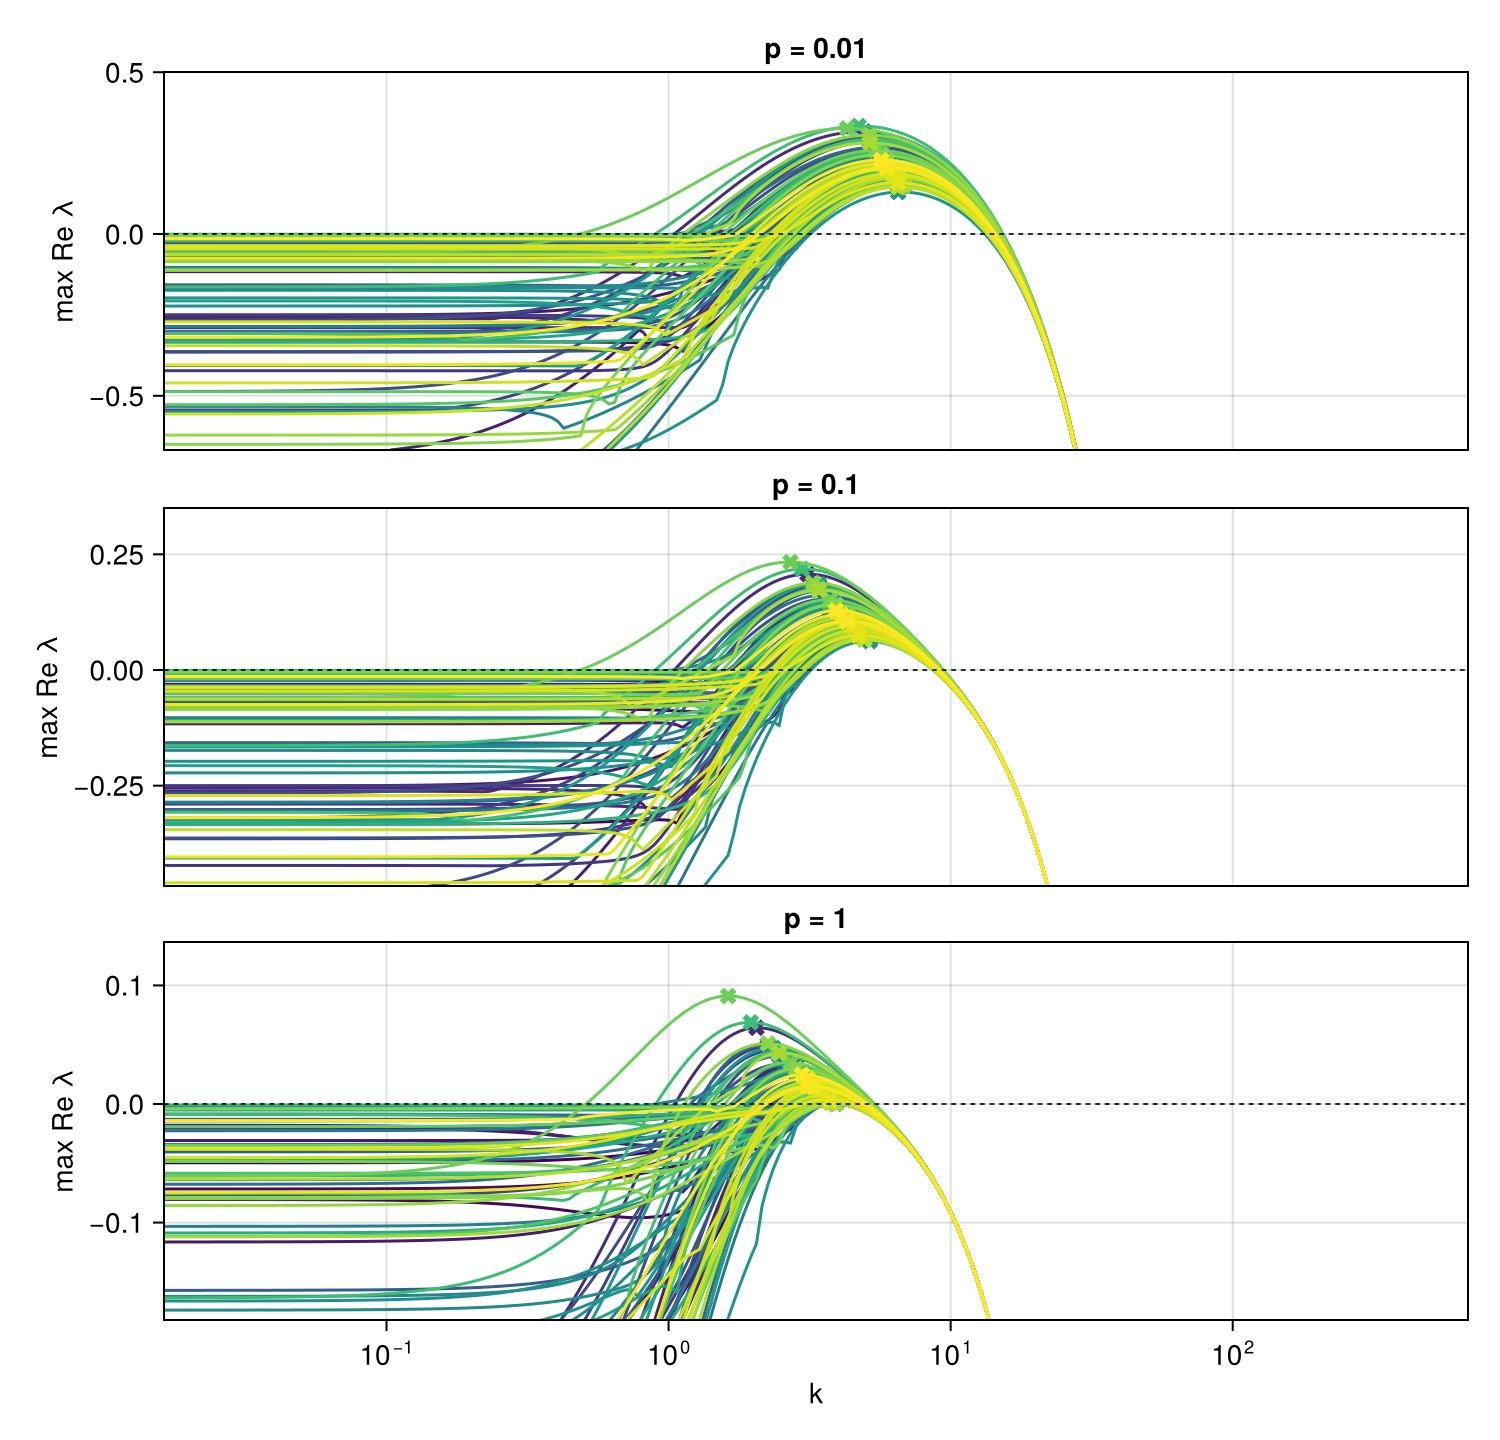

In [11]:
colors = Makie.resample_cmap(:viridis, max(nrow(df), 2))

fig = Figure(; size=(750, 240 * length(ps)))
axs = map(eachindex(ps)) do j
    Axis(fig[j, 1]; xscale=log10, ylabel="max Re λ", title=@sprintf("p = %g", ps[j]))
end
axs[end].xlabel = "k"

for j in eachindex(ps)
    for i in 1:nrow(df)
        lines!(axs[j], ks, mrls[i, j]; color=colors[i])
        scatter!(axs[j], [peak_ks[i, j]], [peak_hs[i, j]];
            color=colors[i], marker=:xcross, markersize=12)
    end
    hlines!(axs[j], 0.0; color=:black, linestyle=:dash, linewidth=0.8)
    mm = maximum(peak_hs[:, j]) # scale each panel by its own tallest peak
    ylims!(axs[j], -2mm, 1.5mm)
end

linkxaxes!(axs...)
# zoom onto where the peaks actually are rather than the whole scanned range
pkext = extrema(peak_ks)
# on all of them, not just the linked one - an axis left on autolimits pulls the
# whole link back out to the full ks range
xlims!.(axs, pkext[1] / 100, pkext[2] * 100)
hidexdecorations!.(axs[1:end-1]; grid=false)
rowgap!(fig.layout, 8)

fig

In [12]:
# One L per (system, p), each sized to fit exactly num_peaks peaks of that
# system's peak k at that p. Every run therefore starts with the same peak count
# and, since sN is shared, the same resolution per peak - only L differs.
Ls = choose_L.(peak_ks, num_peaks)

sizes_df = DataFrame(; df_row=df.df_row)
for j in eachindex(ps)
    sizes_df[!, @sprintf("k_p%g", ps[j])] = peak_ks[:, j]
    sizes_df[!, @sprintf("L_p%g", ps[j])] = Ls[:, j]
end
@show nrow(sizes_df)
first(sizes_df, 10)

nrow(sizes_df) = 100

Row,df_row,k_p0.01,L_p0.01,k_p0.1,L_p0.1,k_p1,L_p1
,Int64,Float64,Float64,Float64,Float64,Float64,Float64
1,4670,6.22257,1.00974,4.50056,1.39609,3.57079,1.75961
2,3472,6.51734,0.964072,4.93705,1.27266,3.73994,1.68002
3,4641,5.94113,1.05757,4.297,1.46222,3.25509,1.93027
4,4475,6.82607,0.920469,4.93705,1.27266,3.9171,1.60404
5,3098,5.67243,1.10767,3.73994,1.68002,2.8331,2.21778
6,151,5.94113,1.05757,4.10266,1.53149,3.10787,2.0217
7,2214,5.94113,1.05757,4.50056,1.39609,3.40929,1.84296
8,1777,5.41587,1.16014,3.73994,1.68002,2.70496,2.32284
9,1926,5.41587,1.16014,3.73994,1.68002,2.8331,2.21778


In [13]:
Random.seed!(seed)

u0s = map(1:nrow(df)) do i
    Ns, Nr = get_Ns(df.params[i])
    perturb_u0_uniform_prop(Ns, Nr, expand_u0_to_size((sN,), df.final_states[i]), epsilon)
end

@show length(u0s) size(u0s[1])
extrema(Ls ./ sN) # dx range

length(u0s) = 100
size(u0s[1]) = (24, 250)

(0.003681874706113069, 0.015459113412591778)

In [14]:
# One row per (system, p) - everything a PDE run needs bar the tolerances and
# maxtime, which are left to whoever runs it.
sysjs = [(i, j) for i in 1:nrow(df) for j in eachindex(ps)]

pde_df = DataFrame(;
    df_row=[df.df_row[i] for (i, _) in sysjs],  # index into the original df
    sys_i=getindex.(sysjs, 1),                 # index into gdf / u0s
    p=[ps[j] for (_, j) in sysjs],
    params=[df.params[i] for (i, _) in sysjs],
    ode_params=[df.params[i] for (i, _) in sysjs],          # reduced params the hss was solved for
    ode_hss=[df.final_states[i] for (i, _) in sysjs],       # reduced well-mixed steady state
    Ds=[make_si_Ds(df.params[i], DN, DI, ps[j]) for (i, j) in sysjs],
    L=[Ls[i, j] for (i, j) in sysjs],  # sized to num_peaks peaks of this (system, p)
    sN=fill(sN, length(sysjs)),
    T=fill(T, length(sysjs)),
    u0=[u0s[i] for (i, _) in sysjs],  # same array object across a system's ps
    mrls=[mrls[i, j] for (i, j) in sysjs],  # disprel on metadata.ks, handy to look at
)

metadata = (; K, l, ks, ps, DN, DI, num_peaks, sN, epsilon, seed)
jldsave(out_fname; metadata, pde_df)

@show nrow(pde_df) filesize(out_fname) / 1e6
select(pde_df, Not(:params, :ode_params, :ode_hss, :Ds, :u0, :mrls)) # the big columns just spam the output

nrow(pde_df) = 300
filesize(out_fname) / 1.0e6 = 5.957097

Row,df_row,sys_i,p,L,sN,T
,Int64,Int64,Float64,Float64,Int64,Float64
1,4670,1,0.01,1.00974,250,1.0e8
2,4670,1,0.1,1.39609,250,1.0e8
3,4670,1,1.0,1.75961,250,1.0e8
4,3472,2,0.01,0.964072,250,1.0e8
5,3472,2,0.1,1.27266,250,1.0e8
6,3472,2,1.0,1.68002,250,1.0e8
7,4641,3,0.01,1.05757,250,1.0e8
8,4641,3,0.1,1.46222,250,1.0e8
9,4641,3,1.0,1.93027,250,1.0e8
